# Algoritmo de Dijkstra — Caminhos Mínimos
**Análise e Projeto de Algoritmos**

Demonstração passo-a-passo com implementação própria de:
- Min-heap binário indexado (`src/min_heap.py`)
- Estrutura de grafo via lista de adjacência (`src/graph.py`)
- Dijkstra com heap O((V + E) log V) (`src/dijkstra.py`)


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt

from src.graph import Graph
from src.dijkstra import dijkstra, shortest_path
from src.dijkstra_traced import dijkstra_trace
from src.visualization import render_step, render_legend, animate_dijkstra


## 1. Construindo o grafo
Grafo não-direcionado com 5 vértices e 6 arestas. Origem **A**, destino qualquer vértice alcançável.


In [2]:
graph = Graph(directed=False)
graph.add_edge('A', 'B', 4)
graph.add_edge('A', 'C', 1)
graph.add_edge('C', 'B', 2)
graph.add_edge('B', 'D', 1)
graph.add_edge('C', 'D', 5)
graph.add_edge('D', 'E', 3)

positions = {
    'A': (0.0, 1.0),
    'B': (-1.0, 0.2),
    'C': (1.0, 0.2),
    'D': (-0.6, -1.0),
    'E': (0.8, -1.0),
}

print(f'V = {graph.vertex_count()}, E = {graph.edge_count()}')


V = 5, E = 6


## 2. Legenda de cores
Útil para acompanhar a animação.


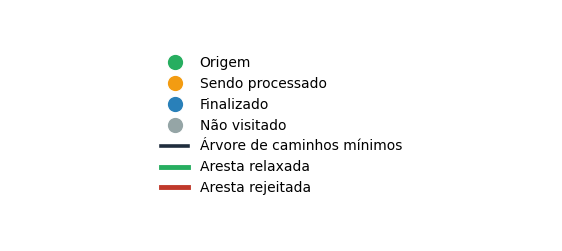

In [3]:
figure, axis = plt.subplots(figsize=(7, 3))
render_legend(axis)
plt.show()


## 3. Passo-a-passo
Cada chamada a `next(steps)` avança o algoritmo em um evento: inicialização, extract-min, ou relaxamento de uma aresta.


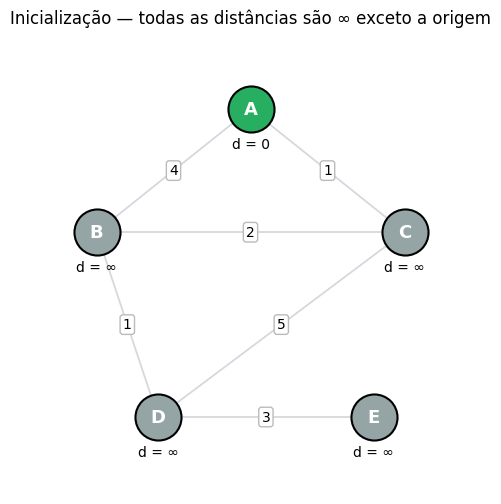

In [4]:
steps = dijkstra_trace(graph, 'A')

def show_next():
    state = next(steps)
    figure, axis = plt.subplots(figsize=(7, 6))
    render_step(graph, positions, state, 'A', axis)
    plt.show()
    return state

show_next();


Avance célula por célula durante a apresentação:


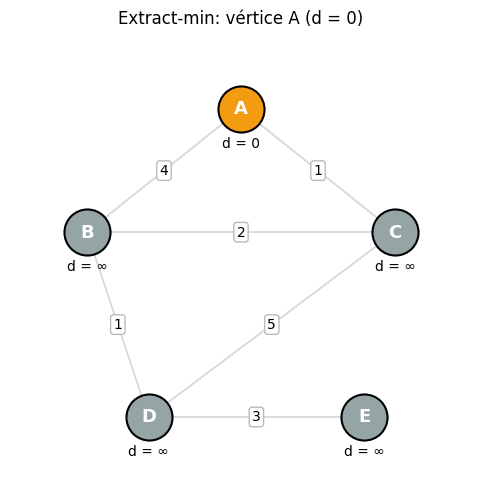

In [5]:
show_next();


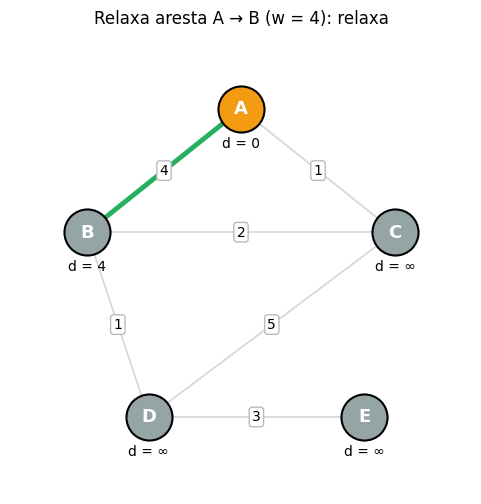

In [6]:
show_next();


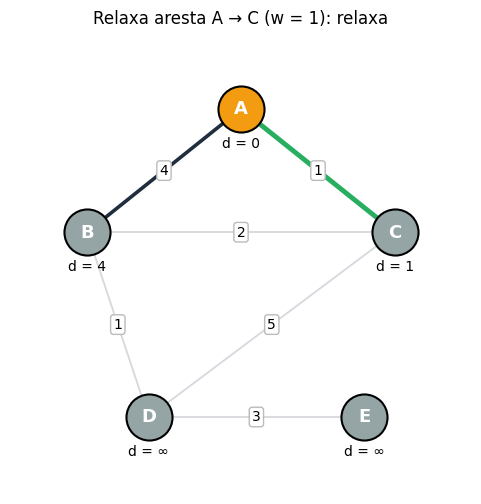

In [7]:
show_next();


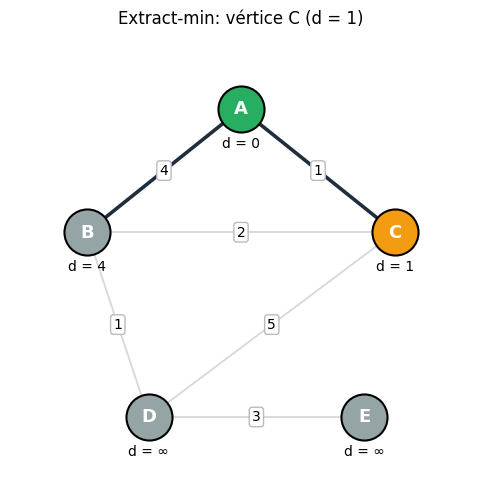

In [8]:
show_next();


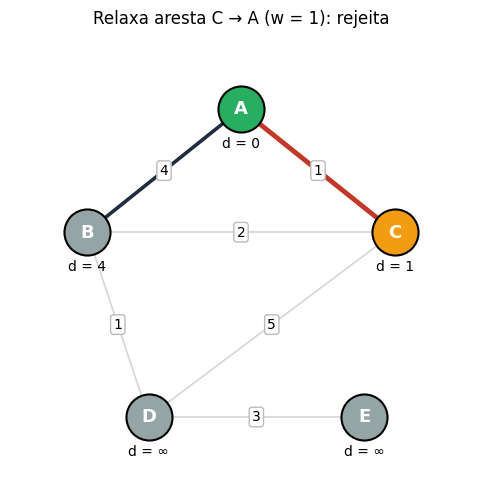

In [9]:
show_next();


## 4. Animação completa
Útil para revisar a execução no fim da apresentação.


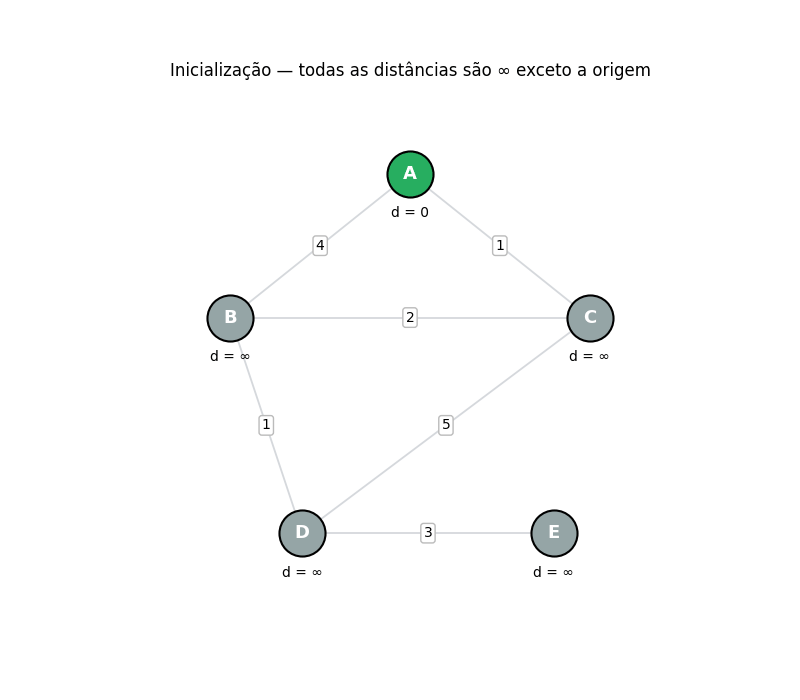

In [10]:
from IPython.display import Image

Image(filename='../results/dijkstra_animation.gif')


## 5. Resultado final
Distâncias mínimas e caminhos reconstruídos a partir de A.


In [11]:
distances, predecessors = dijkstra(graph, 'A')
for vertex in sorted(distances):
    path, cost = shortest_path(graph, 'A', vertex)
    pretty_path = ' → '.join(path) if path else '(inalcançável)'
    print(f'A → {vertex}:  distância = {cost}    caminho = {pretty_path}')


A → A:  distância = 0    caminho = A
A → B:  distância = 3    caminho = A → C → B
A → C:  distância = 1    caminho = A → C
A → D:  distância = 4    caminho = A → C → B → D
A → E:  distância = 7    caminho = A → C → B → D → E


## 6. Verificação cruzada
Versão naive O(V²) deve produzir o mesmo resultado.


In [12]:
from src.dijkstra_naive import dijkstra_naive

naive_distances, _ = dijkstra_naive(graph, 'A')
assert naive_distances == distances
print('OK — heap e naive concordam.')


OK — heap e naive concordam.


## 7. Análise empírica
Resultados do `benchmarks/complexity_analysis.py`:

**Grafo esparso (E ≈ 3V):** speedup do heap cresce de 1.5× (V=100) para 22× (V=3200) — confirma O((V+E) log V) vs O(V²).

**Grafo denso (p=0.5):** speedup pequeno (1-1.8×). Em V=50 a versão naive até vence — em grafos densos E ≈ V², o overhead do heap deixa de compensar.

**Conclusão:** densidade do grafo determina a escolha. Heap para grafos esparsos (ex. malhas viárias), naive ou matriz para densos.


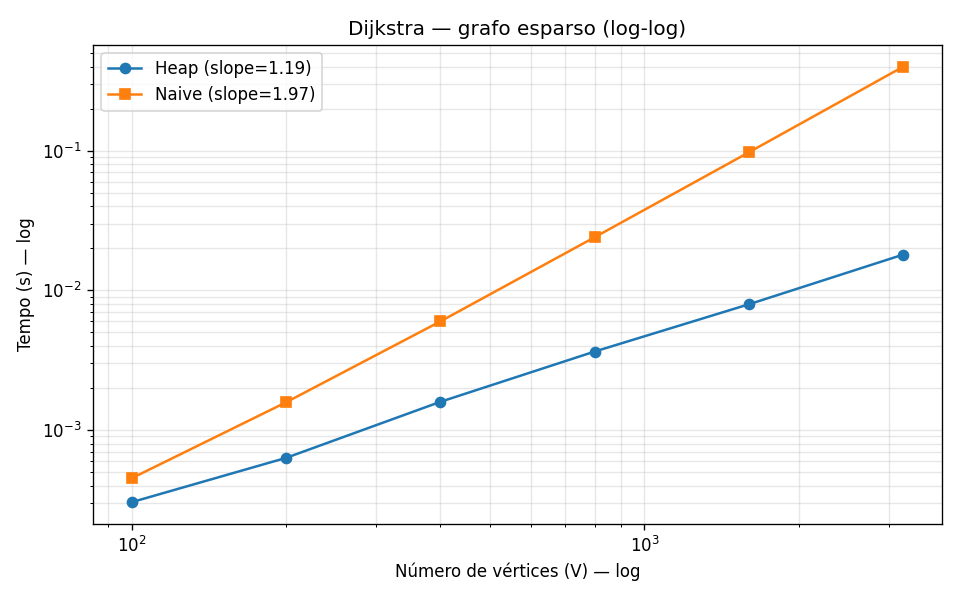

In [13]:
from IPython.display import Image
Image(filename='../results/sparse_loglog.png')


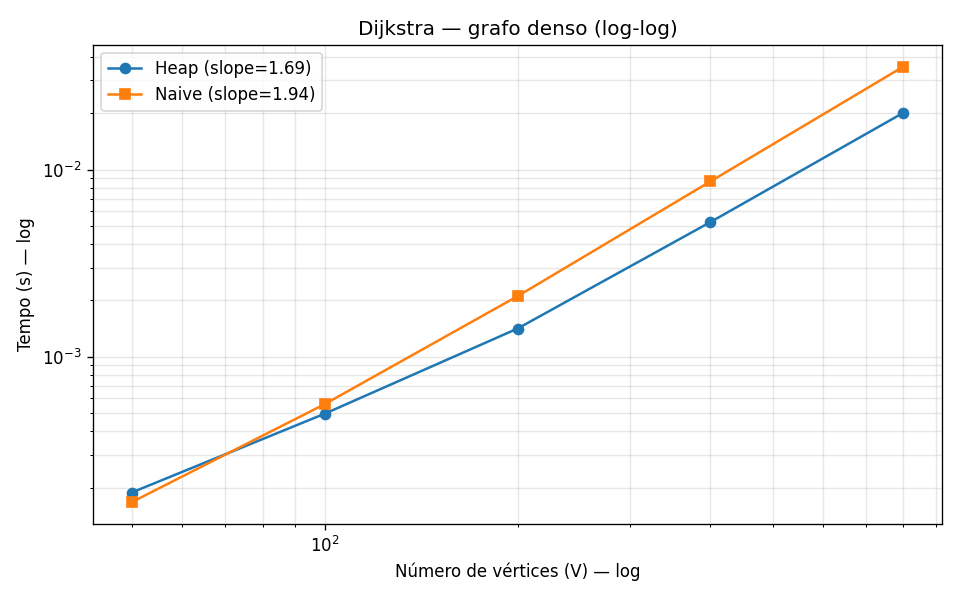

In [14]:
Image(filename='../results/dense_loglog.png')
